In [4]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
#extraer los datos de mySQL y crear un DataFrame de pandas
def extract_data_from_mysql(query):
    

    # Configuración de la conexión a la base de datos
    config = {
        'user': 'root',
        'password': 'larisis5087',
        'host': 'localhost',
        'database': 'proyecto_final',
    }

    # Establecer la conexión
    conn = mysql.connector.connect(**config)

    # Consulta SQL
    # query = "SELECT * FROM proyecto_final.dataset_fao"

    # Crear DataFrame
    df_emisiones = pd.read_sql(query, conn)

    # Cerrar la conexión
    conn.close()
    return df_emisiones
  



C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_3408\875099439.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


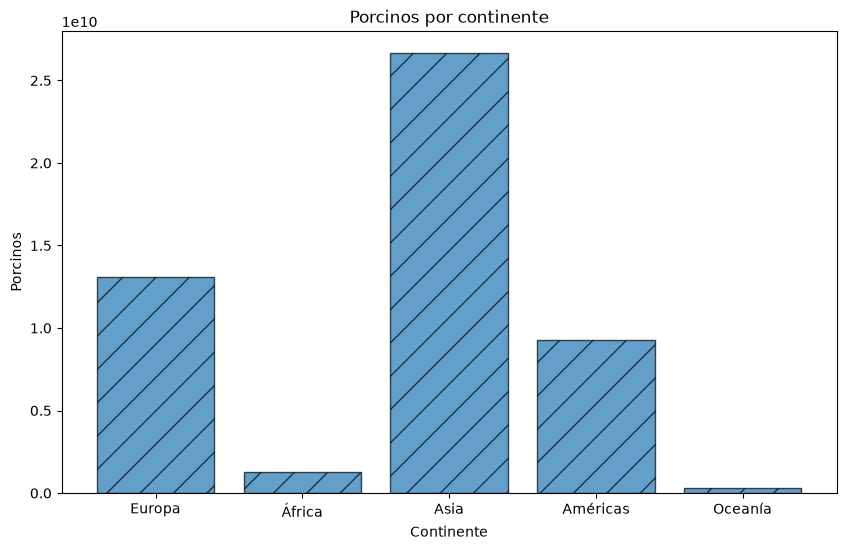

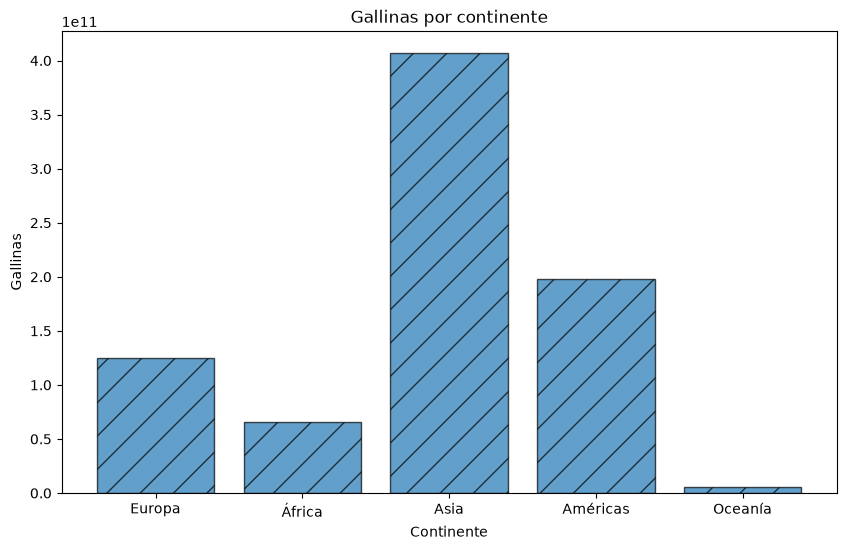

In [25]:
df_emisiones_N2O = extract_data_from_mysql("""SELECT * FROM proyecto_final.dataset_fao where codigo_elemento = 72431""") #df con emisiones de N2O


'''
# gráfico con matplotlib de evolución de emisiones para cada continente 
def matplotlib_evolucion_emisiones_continente(df_emisiones,continente):
    plt.figure(figsize=(10, 6))
    plt.plot(df_emisiones['anio'], df_emisiones['valor'], label=continente)
    plt.title('Evolución de emisiones por continente')
    plt.xlabel('Año')
    plt.ylabel('Emisiones')
    plt.legend()
    plt.grid()
    plt.show()
'''




#matplotlib_evolucion_emisiones_continente(df_emisiones_N2O, 'Oceania')


## gráfico porcinos por continente

def matplotlib_especie_continente(df, especie):
    plt.figure(figsize=(10,6))
    plt.title(f'{especie} por continente')
    plt.bar(df['area'], df['valor'], alpha=0.7, edgecolor='black', hatch='/')
    plt.xlabel('Continente')
    plt.ylabel(especie)
    plt.show()

df_porcinos=extract_data_from_mysql("""SELECT area, sum(valor) as valor FROM proyecto_final.dataset_fao where (producto = 'Porcinos de carne' or producto = 'Porcinos de cría') and elemento = 'Existencias' group by area""") #df con porcinos 
matplotlib_especie_continente(df_porcinos, 'Porcinos')

df_gallinas= extract_data_from_mysql("""SELECT area, sum(valor) as valor FROM proyecto_final.dataset_fao where (producto = 'Gallinas, parrilleros' or producto = 'Gallinas, ponedoras') and elemento = 'Existencias' group by area""") #df con gallinas
matplotlib_especie_continente(df_gallinas, 'Gallinas')





In [26]:
print(df_porcinos.head)

<bound method NDFrame.head of        area         valor
0    Europa  1.310017e+10
1    África  1.262027e+09
2      Asia  2.665998e+10
3  Américas  9.288687e+09
4   Oceanía  2.928702e+08>


<bound method NDFrame.head of      anio       valor
0    1990  82022964.0
1    1991  79677475.0
2    1992  68371763.0
3    1993  66090242.0
4    1994  65016314.0
..    ...         ...
105  1996  31002304.0
106  1997  31284373.0
107  1998  30893484.0
108  1999  30727533.0
109  2000  31793245.0

[110 rows x 2 columns]>


C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_3408\875099439.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


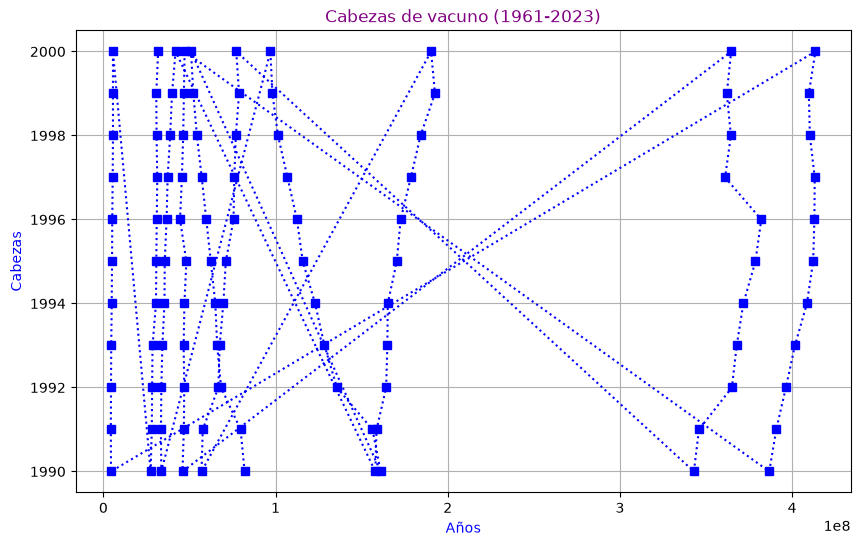

In [ ]:
## Gráfico de líneas

#df con vacunos
df_vacunos = extract_data_from_mysql("""select anio, valor from proyecto_final.dataset_fao where (producto = 'Vacas lecheras' or producto = 'Vacunos, otros') and elemento = 'Existencias' and anio between 1990 and 2000 """)

print(df_vacunos.head)


def lineaPlot(df): 
    plt.figure(figsize= (10,6))#tamaño del lienzo en pulgadas (ancho x alto)
    plt.plot(df['anio'], df['valor'], linestyle = ':', color ='blue', marker = 's')
    plt.xlabel('Años', color = 'blue')
    plt.ylabel('Cabezas', color = 'blue')
    plt.grid()#marca la cuadrícula por debajo 
    plt.title('Cabezas de vacuno (1990-2000)', color = 'purple')
    plt.show()

lineaPlot(df_vacunos)
